In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import os
import sys
import glob
import itertools as it
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams['font.family'] = 'serif'
import seaborn as sns

import gwpy.table
import cogwheel.cosmology
from cogwheel import utils, gw_plotting, plotting
from cogwheel.likelihood.marginalization.coherent_score_lensing import bayes_factor_p_lensed, \
                                                                        get_bayes_factor_of_samples, \
                                                                        bootstrap_bayes_factors

sys.path.insert(0, '/home/abbye.williams/GWPE/code')
import helpers
from injections import create_injection, lens_event

/home/abbye.williams/venv/gwaves_pe/lib/python3.12/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


#### which events have $\ln\mathcal B < 0$?

In [3]:
# load the relevant data

approximant = 'IMRPhenomXPHM'
# get the SNR and compute the Bayes factor
resdir = f'/home/abbye.williams/GWPE/data/injections/Halton/{approximant}/IntrinsicLVCPrior'
seed = 12
nevents = 100

idx_existing = []
# things to save: keys will be the event idx
lnBayes = {}
rhosqs = {}

# parameters if we want to compute
n_resamples = 1000

for idx in range(nevents):
    # load the sampler for this event
    eventname = f'GW{seed}_{idx}'
    try:
        event_data, samples, samples_dir = helpers.load_event_data_and_posterior_samples(os.path.join(resdir, eventname), eventname)
    except FileNotFoundError:
        print(f"no samples for idx {idx}. continuing")
        continue

    lnBayes_fn = os.path.join(samples_dir, 'lnBayes.npy')
    try:
        lnBayes[idx] = np.load(lnBayes_fn)
        if np.isnan(lnBayes[idx][0]):
            lnBayes[idx] = np.array([30., 0.])
    except FileNotFoundError:
        bayes_factors = bootstrap_bayes_factors(samples, n_resamples)
        # log these
        lnBayes_factors = np.log(bayes_factors)
        # get the median and standard deviation
        lnBayes[idx] = (np.median(lnBayes_factors), np.std(lnBayes_factors))
        np.save(lnBayes_fn, lnBayes[idx])

loaded posterior samples for GW12_0 run 0
loaded posterior samples for GW12_1 run 0
loaded posterior samples for GW12_2 run 0
loaded posterior samples for GW12_3 run 0
loaded posterior samples for GW12_4 run 0
loaded posterior samples for GW12_5 run 0
loaded posterior samples for GW12_6 run 0
loaded posterior samples for GW12_7 run 0
loaded posterior samples for GW12_8 run 0
loaded posterior samples for GW12_9 run 0
loaded posterior samples for GW12_10 run 0
loaded posterior samples for GW12_11 run 0
loaded posterior samples for GW12_12 run 0
loaded posterior samples for GW12_13 run 0
loaded posterior samples for GW12_14 run 0
loaded posterior samples for GW12_15 run 0
loaded posterior samples for GW12_16 run 0
no samples for idx 17. continuing
loaded posterior samples for GW12_18 run 0
loaded posterior samples for GW12_19 run 0
loaded posterior samples for GW12_20 run 0
loaded posterior samples for GW12_21 run 0
loaded posterior samples for GW12_22 run 0
loaded posterior samples for G

In [4]:
# which events have negative lnB?
threshold = -1.
negative_lnB = {}
subset = {}
for idx, (lnB, lnB_std) in lnBayes.items():
    if lnB < 0:
        negative_lnB[idx] = (lnB, lnB_std)
        print(f"{idx:<8}:\tlnB = {lnB:.5f} ± {lnB_std:.5f}")
        if lnB < threshold:
            subset[idx] = (lnB, lnB_std)

10      :	lnB = -0.03420 ± 0.00290
14      :	lnB = -2.62839 ± 0.03179
24      :	lnB = -0.06467 ± 0.00920
25      :	lnB = -0.05350 ± 0.00156
36      :	lnB = -0.57445 ± 0.00704
38      :	lnB = -1.59746 ± 0.01983
59      :	lnB = -0.48689 ± 0.01812
63      :	lnB = -0.38064 ± 0.00374
74      :	lnB = -4.94672 ± 0.08330
83      :	lnB = -0.04285 ± 0.00514
84      :	lnB = -0.70598 ± 0.01471
86      :	lnB = -0.00389 ± 0.00086
88      :	lnB = -0.24205 ± 0.00740
96      :	lnB = -1.35768 ± 0.01224


In [5]:
len(negative_lnB)

14

In [6]:
print(f"events with lnB < {threshold}:")
for idx, (lnB, lnB_std) in subset.items():
    print(f"{idx:<8}:\tlnB = {lnB:.3f} ± {lnB_std:.3f}")

events with lnB < -1.0:
14      :	lnB = -2.628 ± 0.032
38      :	lnB = -1.597 ± 0.020
74      :	lnB = -4.947 ± 0.083
96      :	lnB = -1.358 ± 0.012


In [7]:
# what are the parameters of these events?
for idx in subset.keys():
    # load the sampler for this event
    eventname = f'GW{seed}_{idx}'
    event_data, samples, samples_dir = helpers.load_event_data_and_posterior_samples(os.path.join(resdir, eventname), eventname)
    # SNR?
    snr = np.sqrt(np.sum(event_data.injection['h_h']))
    print(f"SNR = {snr:.1f}")
    inj_par_dic = event_data.injection['par_dic']
    helpers.add_derived_quantities_injection(inj_par_dic)
    for par, val in inj_par_dic.items():
        if par not in ['f_ref', 'l1', 'l2']:
            print(f"{par:<12}:{val:>10.4f}")

loaded posterior samples for GW12_14 run 0
SNR = 62.4
m1          :  223.5945
m2          :   18.1598
s1z         :   -0.7529
s2z         :   -0.3499
psi         :    1.3911
iota        :    1.4002
s1x_n       :   -0.1512
s1y_n       :   -0.1541
s2x_n       :   -0.3645
s2y_n       :   -0.0723
ra          :    5.6400
dec         :   -0.3631
t_geocenter :    0.0434
phi_ref     :    3.1569
d_luminosity:   90.5127
mchirp      :   48.8055
q           :    0.0812
chieff      :   -0.7227
chip        :    0.0466
loaded posterior samples for GW12_38 run 0
SNR = 21.1
m1          :  255.7751
m2          :   15.4530
s1z         :   -0.2183
s2z         :    0.0723
psi         :    0.7420
iota        :    0.6434
s1x_n       :    0.4546
s1y_n       :    0.7090
s2x_n       :    0.0083
s2y_n       :    0.4073
ra          :    0.8377
dec         :    0.0208
t_geocenter :   -0.0506
phi_ref     :    0.2273
d_luminosity:  190.0935
mchirp      :   46.9305
q           :    0.0604
chieff      :   -0.2018
chip

In [8]:
# for this subset, what are the Bayes factors that we get from the rerun?
lnBayes_rerun = {}
n_resamples = 1000

for idx in subset.keys():
    # load the sampler for this event
    eventname = f'GW{seed}_{idx}_rerun_neg'
    event_data, samples, samples_dir = helpers.load_event_data_and_posterior_samples(os.path.join(resdir, eventname), eventname)

    lnBayes_fn = os.path.join(samples_dir, 'lnBayes.npy')
    try:
        lnBayes_rerun[idx] = np.load(lnBayes_fn)
        if np.isnan(lnBayes_rerun[idx][0]):
            lnBayes_rerun[idx] = np.array([30., 0.])
    except FileNotFoundError:
        bayes_factors = bootstrap_bayes_factors(samples, n_resamples)
        # log these
        lnBayes_factors = np.log(bayes_factors)
        # get the median and standard deviation
        lnBayes_rerun[idx] = (np.median(lnBayes_factors), np.std(lnBayes_factors))
        np.save(lnBayes_fn, lnBayes_rerun[idx])

loaded posterior samples for GW12_14_rerun_neg run 0
loaded posterior samples for GW12_38_rerun_neg run 0
loaded posterior samples for GW12_74_rerun_neg run 0
loaded posterior samples for GW12_96_rerun_neg run 0


In [9]:
c1 = 'cornflowerblue'
c2 = 'mediumseagreen'

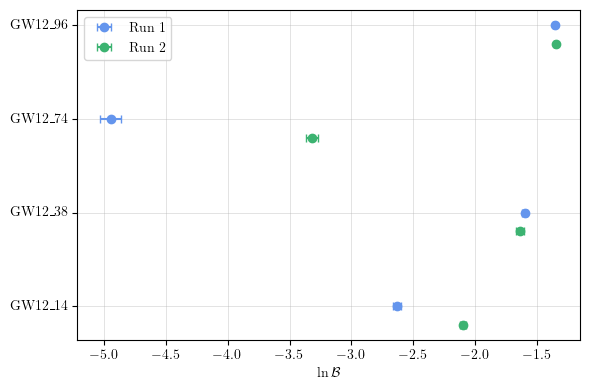

In [10]:
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(6,4), tight_layout=True)
kwargs = dict(marker='o', capsize=3, ls='None')
eventnames = []
for i, idx in enumerate(subset.keys()):
    labels = ['Run 1', 'Run 2'] if i == 0 else [None, None]
    eventname = f'GW{seed}_{idx}'
    eventnames.append(eventname)
    lnB, lnB_std = lnBayes[idx]
    ax.errorbar(lnB, i, xerr=lnB_std, c=c1, label=labels[0], **kwargs)
    lnB, lnB_std = lnBayes_rerun[idx]
    ax.errorbar(lnB, i - 0.2, xerr=lnB_std, c=c2, label=labels[1], **kwargs)
ax.grid(alpha=0.5, lw=0.5)
_ = ax.set_yticks(np.arange(len(subset)), labels=eventnames)
ax.set_xlabel(r'$\ln\mathcal B$')
ax.legend()

#### compare the corner plots

In [11]:
# likelihoods of the injected parameters
lnlikes = {}
for idx in subset.keys():
    eventname = f'GW{seed}_{idx}'
    event_data, _, samples_dir = helpers.load_event_data_and_posterior_samples(os.path.join(resdir, eventname), eventname)
    # load the sampler
    sampler = cogwheel.utils.read_json(os.path.join(samples_dir, 'Sampler.json'))
    # unlens the event data
    ed_u = event_data.reinstantiate(strain=event_data.strain * -1j)
    like = sampler.posterior.likelihood
    like.event_data = ed_u
    lnlikes[idx] = like.lnlike_fft(ed_u.injection['par_dic'])


loaded posterior samples for GW12_14 run 0


loaded posterior samples for GW12_38 run 0
loaded posterior samples for GW12_74 run 0


loaded posterior samples for GW12_96 run 0


In [12]:
lnlikes

{14: np.float64(1915.5544136637),
 38: np.float64(266.3761779297538),
 74: np.float64(995.3004855029835),
 96: np.float64(3167.624190769745)}

In [24]:
idx = 14
eventname = f'GW{seed}_{idx}'
event_data, samples, samples_dir = helpers.load_event_data_and_posterior_samples(os.path.join(resdir, eventname), eventname)

loaded posterior samples for GW12_14 run 0


In [25]:
# load the sampler
sampler = cogwheel.utils.read_json(os.path.join(samples_dir, 'Sampler.json'))
# # unlens the event data
# ed_u = event_data.reinstantiate(strain=event_data.strain * -1j)
# like = sampler.posterior.likelihood
# like.event_data = ed_u
like = sampler.posterior.likelihood

In [30]:
idx_max = np.argmax(samples['lnl_marginalized'])
sample = samples.iloc[idx_max]

In [56]:
# unlens the event data
ed_u = event_data.reinstantiate(strain=event_data.strain * -1j)
like = sampler.posterior.likelihood
like.event_data = ed_u

In [59]:
like.lnlike(like.par_dic_0)

np.float64(1510.0787904016172)

In [61]:
like.lnlike(event_data.injection['par_dic'])

np.float64(1731.4098870940552)

In [62]:
like_nr = like.reinstantiate(par_dic_0=event_data.injection['par_dic'])

In [63]:
like_nr.lnlike(like_nr.par_dic_0)

np.float64(1905.0620066557053)

In [65]:
like_nr.lnlike(event_data.injection['par_dic'])

np.float64(1904.716066801018)

loaded posterior samples for GW12_14 run 0
loaded posterior samples for GW12_14_rerun_neg run 0
loaded posterior samples for GW12_38 run 0
loaded posterior samples for GW12_38_rerun_neg run 0
loaded posterior samples for GW12_74 run 0
loaded posterior samples for GW12_74_rerun_neg run 0
loaded posterior samples for GW12_96 run 0
loaded posterior samples for GW12_96_rerun_neg run 0


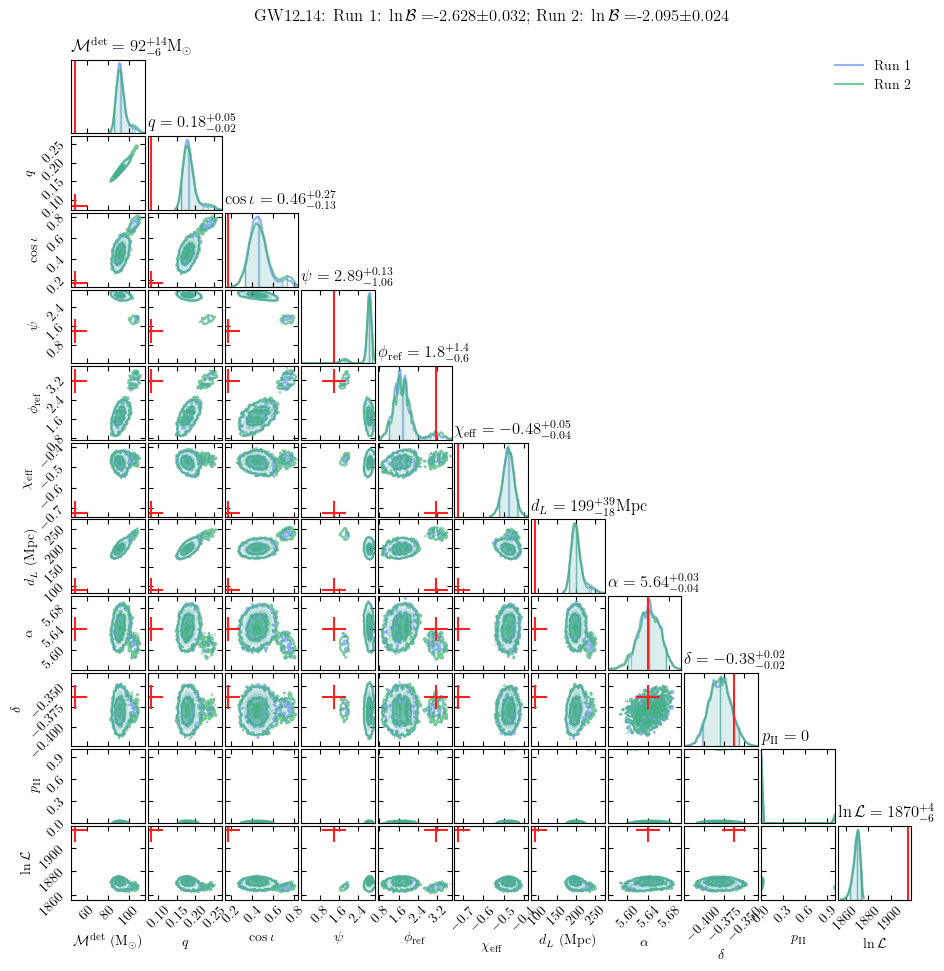

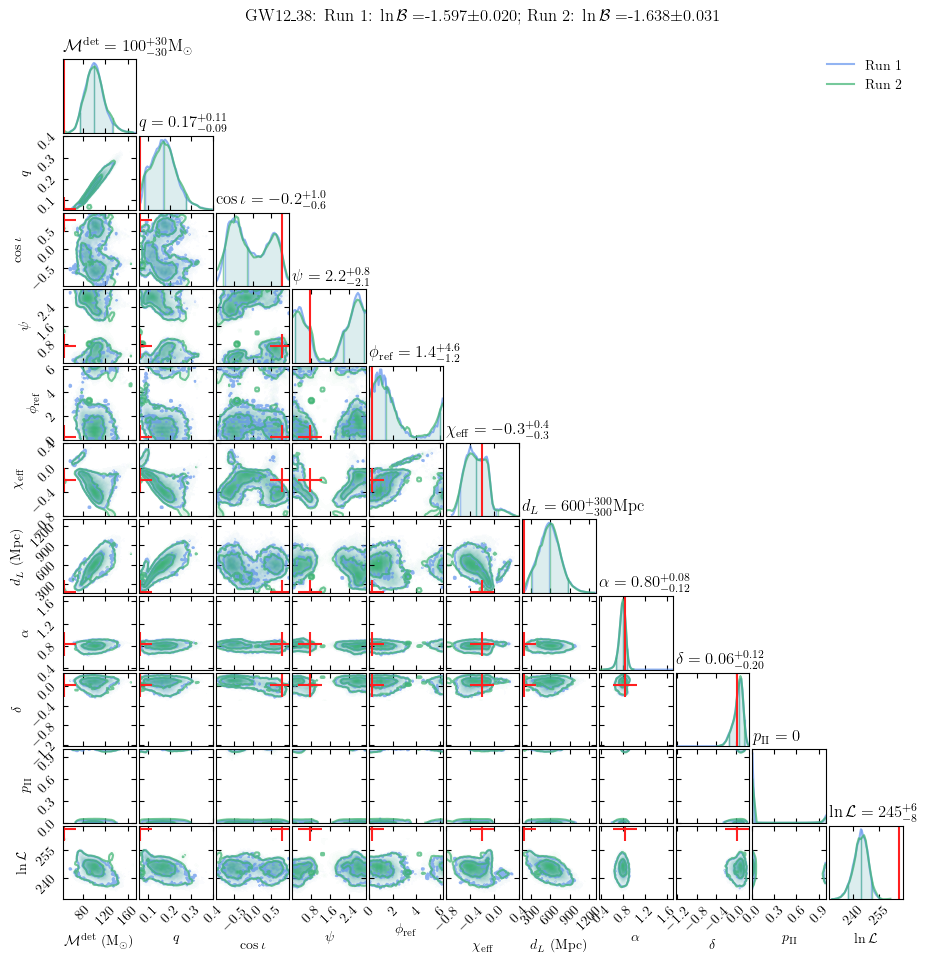

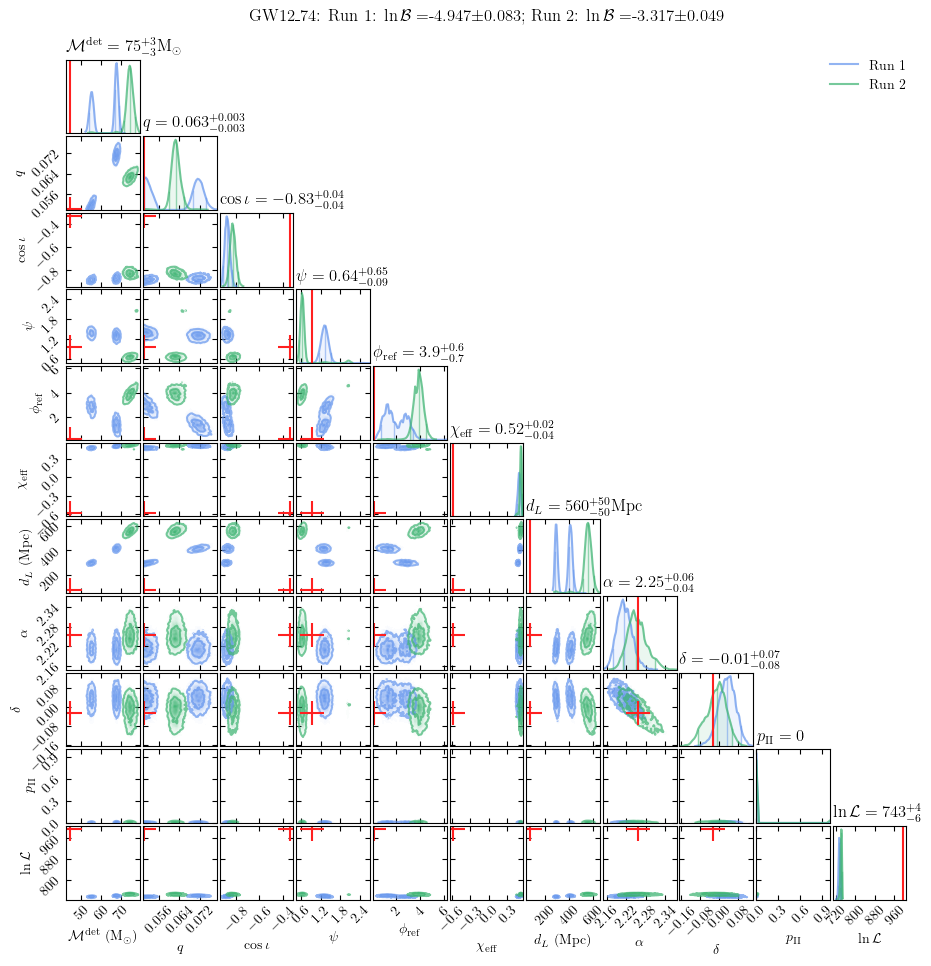

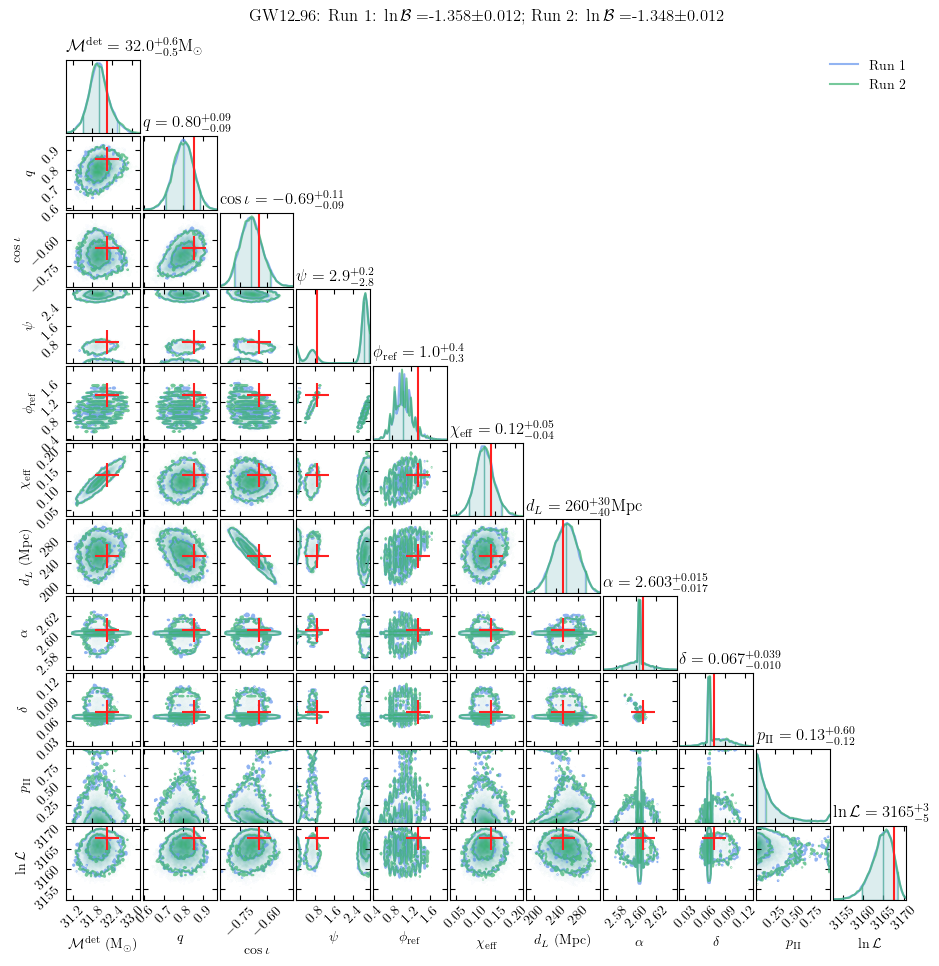

In [13]:
plotstyles = [
        plotting.PlotStyle(color_2d=c1, contour_kwargs=dict(alpha=0.7), kwargs_1d=dict(color=c1, alpha=0.7), tail_probability=1e-3),
        plotting.PlotStyle(color_2d=c2, contour_kwargs=dict(alpha=0.7), kwargs_1d=dict(color=c2, alpha=0.7), tail_probability=1e-3)
]
pars_to_plot = [
    'mchirp', 'q', 'cosiota', 'psi', 'phi_ref', 'chieff', 'd_luminosity', 'ra', 'dec', 'p_lensed', 'lnl'
]
for idx in subset.keys():
    # load this sample
    eventname = f'GW{seed}_{idx}'
    event_data, samples, samples_dir = helpers.load_event_data_and_posterior_samples(os.path.join(resdir, eventname), eventname)
    samples['cosiota'] = np.cos(samples['iota'])
    # the rerun
    eventname_rerun = eventname+'_rerun_neg'
    event_data_rerun, samples_rerun, samples_dir = helpers.load_event_data_and_posterior_samples(os.path.join(resdir, eventname_rerun), eventname_rerun)
    samples_rerun['cosiota'] = np.cos(samples_rerun['iota'])
    cp = gw_plotting.MultiCornerPlot({'Run 1' : samples, 'Run 2' : samples_rerun},
                                                params=pars_to_plot, plotstyles=plotstyles)
    cp.plot(max_figsize=10)
    # injected parameters (these are the same for the original and rerun!)
    inj_par_dic = event_data.get_init_dict()['injection']['par_dic']
    helpers.add_derived_quantities_injection(inj_par_dic)
    inj_par_dic['cosiota'] = np.cos(inj_par_dic['iota'])
    # compute lnL from dh and hh
    inj_par_dic['lnl'] = lnlikes[idx]
    inj_pars_to_plot = {k : v for k, v in inj_par_dic.items() if k in pars_to_plot}
    cp.scatter_points(inj_pars_to_plot, colors=['#FF2020'], s=300,
                                        zorder=2, marker='+', adjust_lims=True)
    lnB = lnBayes[idx]
    lnB_str = 'NaN' if np.isnan(lnB[0]) else f'{lnB[0]:.3f}'r'$\pm$'f'{lnB[1]:.3f}'
    lnB = lnBayes_rerun[idx]
    lnB_str_rerun = 'NaN' if np.isnan(lnB[0]) else f'{lnB[0]:.3f}'r'$\pm$'f'{lnB[1]:.3f}'
    title_str = f'{eventname}: Run 1: 'r'$\ln\mathcal B =$'+lnB_str +r'; Run 2: $\ln\mathcal B =$'+lnB_str_rerun
    cp.corner_plots[0].fig.suptitle(title_str, y=0.97)

Based on the corner plots and reruns, by eye, the PE failed for GW12_14 and GW12_74.
How to quantify this?

In [26]:
lnlikes = {}

loaded posterior samples for GW12_0 run 0
ValueError. continuing to next event.
loaded posterior samples for GW12_1 run 0
ValueError. continuing to next event.
loaded posterior samples for GW12_2 run 0
ValueError. continuing to next event.
loaded posterior samples for GW12_3 run 0
loaded posterior samples for GW12_4 run 0
loaded posterior samples for GW12_5 run 0
loaded posterior samples for GW12_6 run 0


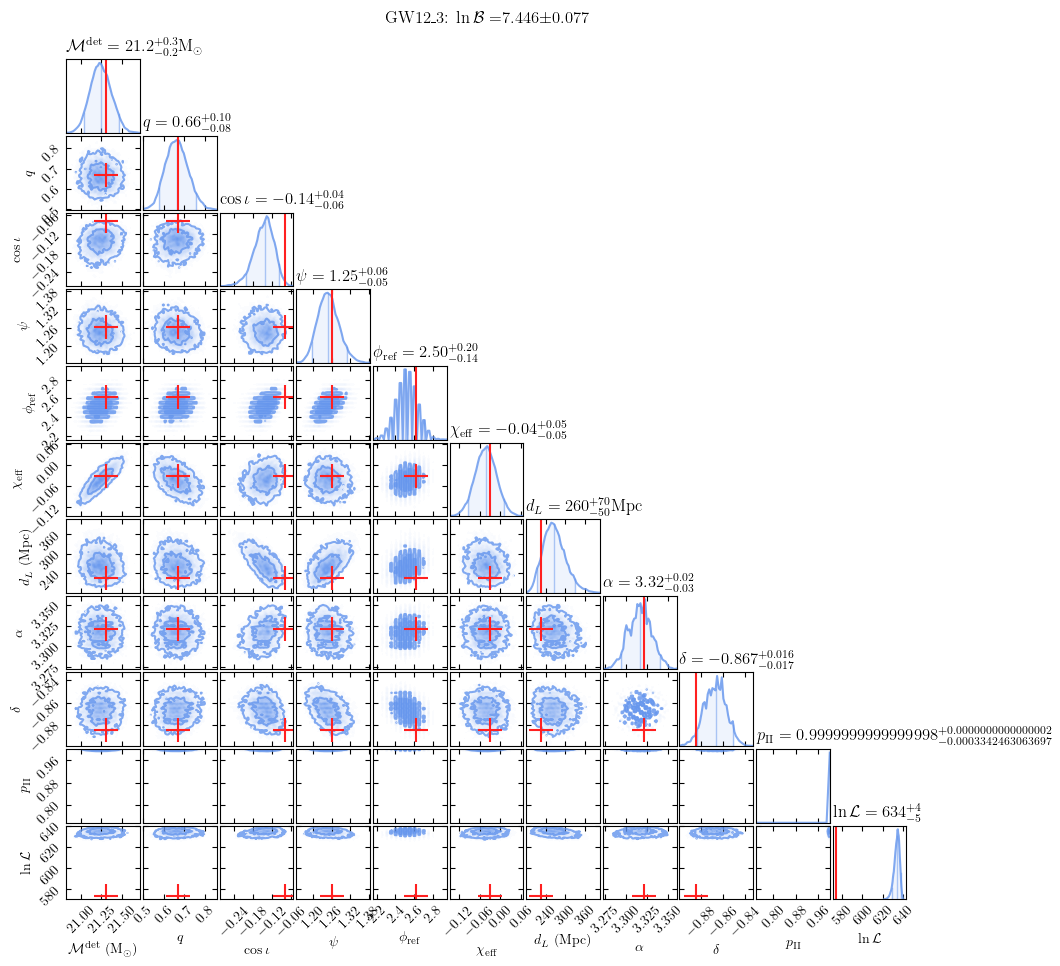

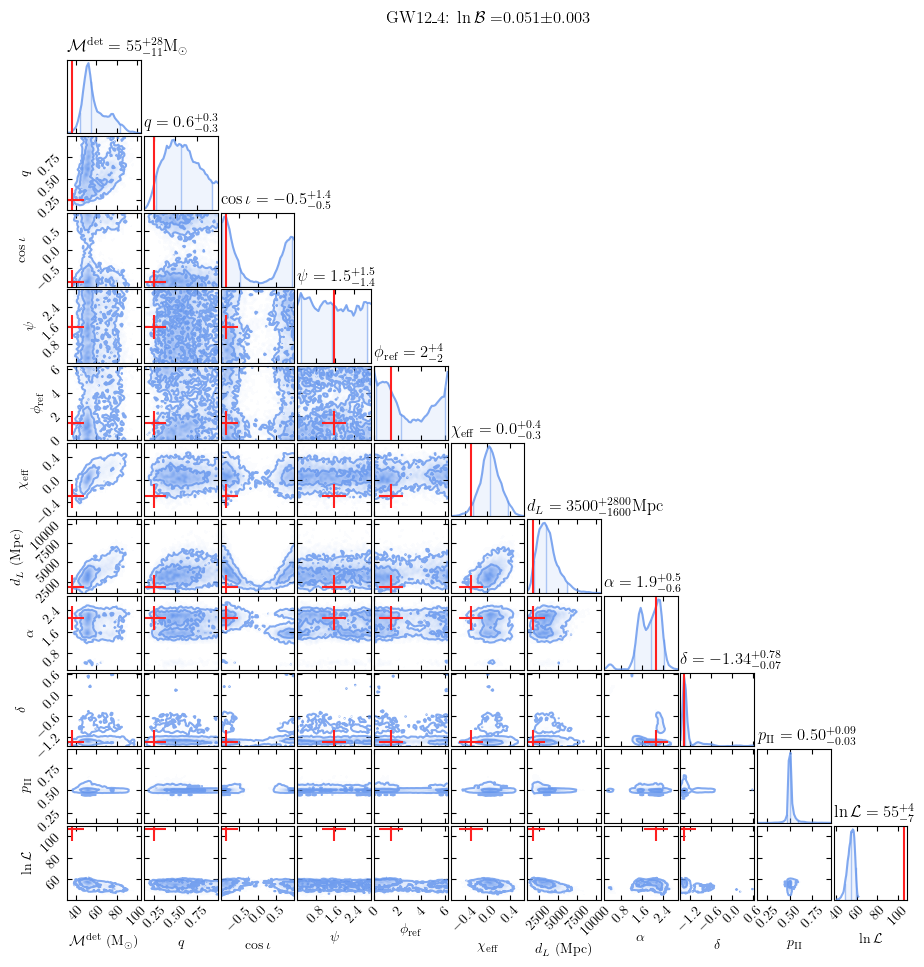

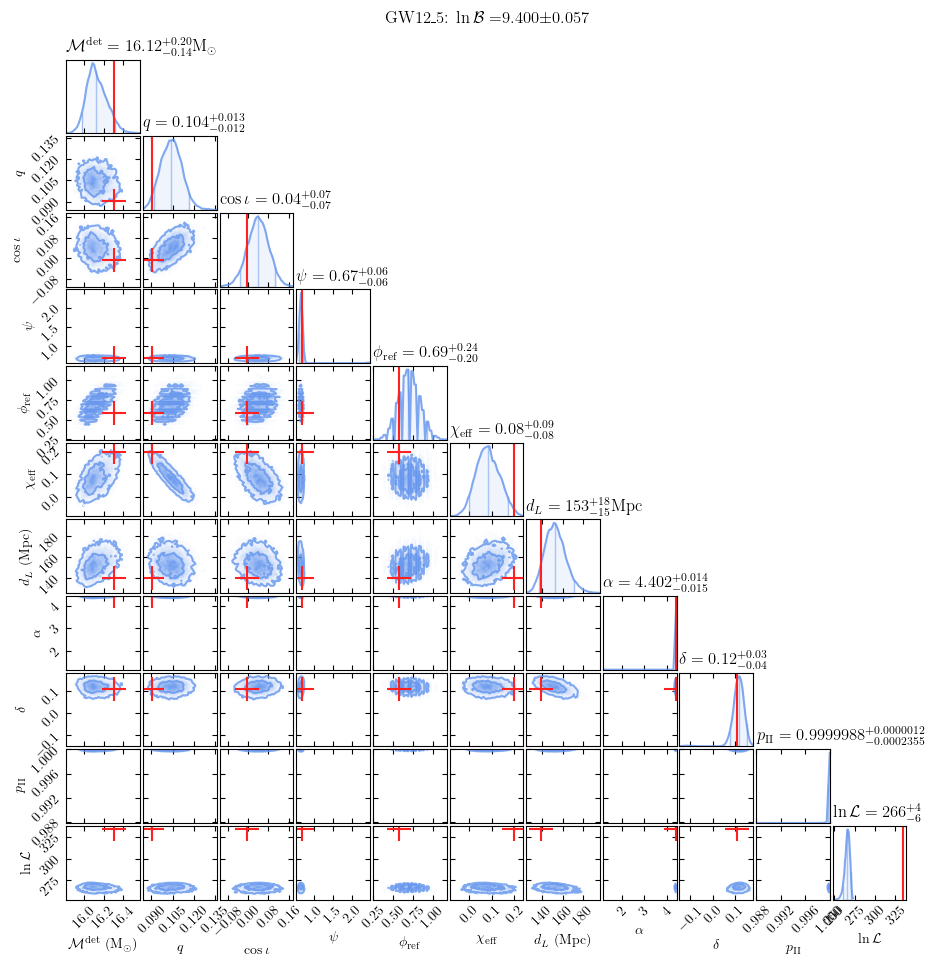

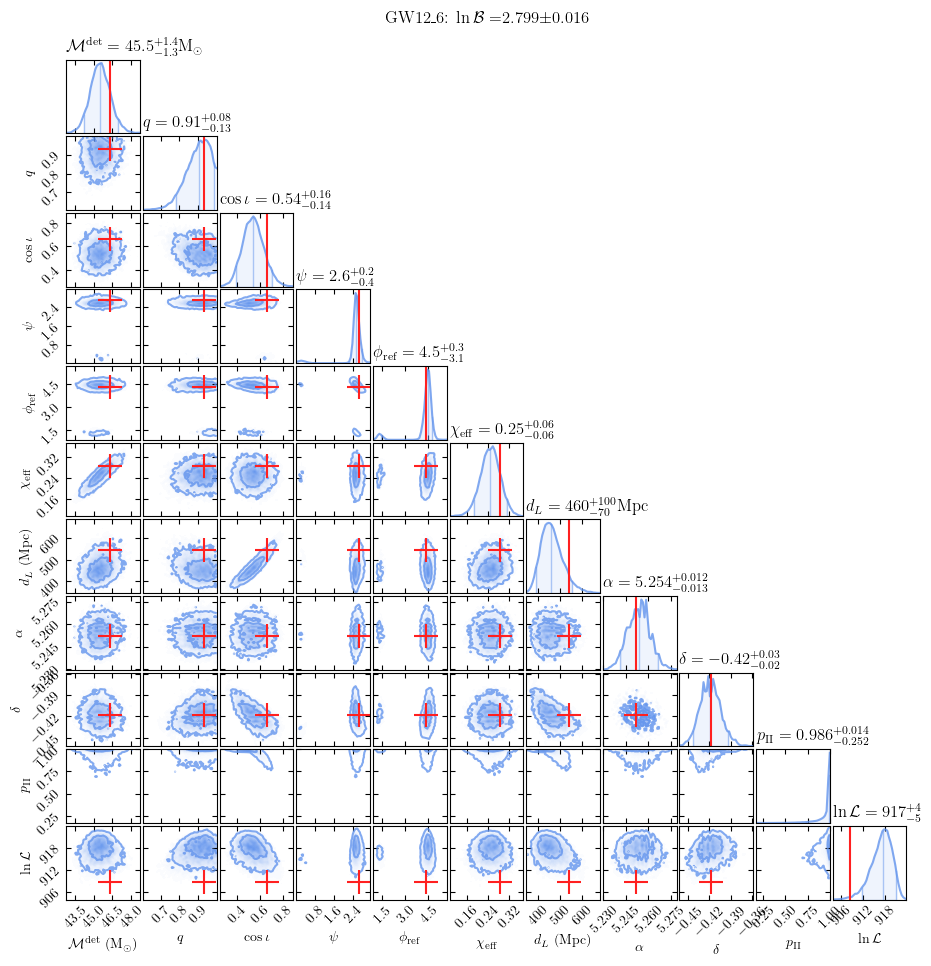

In [28]:
# do this for a few events
nevents = 7
corner_plot_kwargs = dict(tail_probability=1e-3, color_2d=c1,
                          kwargs_1d=dict(color=c1, alpha=0.8), contour_kwargs=dict(alpha=0.8))
pars_to_plot = [
    'mchirp', 'q', 'cosiota', 'psi', 'phi_ref', 'chieff', 'd_luminosity', 'ra', 'dec', 'p_lensed', 'lnl'
]
for idx in range(nevents):
    # load this sample
    eventname = f'GW{seed}_{idx}'
    try:
        event_data, samples, samples_dir = helpers.load_event_data_and_posterior_samples(os.path.join(resdir, eventname), eventname)
    except FileNotFoundError:
        print(f"no samples for {eventname}. continuing")
    samples['cosiota'] = np.cos(samples['iota'])

    cp = gw_plotting.CornerPlot(samples, params=pars_to_plot, **corner_plot_kwargs)
    try:
        cp.plot(max_figsize=10)
    except ValueError:
        print(f"ValueError. continuing to next event.")
        plt.close(cp.fig)
        continue
    # injected parameters (these are the same for the original and rerun!)
    inj_par_dic = event_data.get_init_dict()['injection']['par_dic']
    helpers.add_derived_quantities_injection(inj_par_dic)
    inj_par_dic['cosiota'] = np.cos(inj_par_dic['iota'])
    try:
        inj_par_dic['lnl'] = lnlikes[idx]
    except KeyError:
        print(f"loading sampler for {eventname}")
        sampler = cogwheel.utils.read_json(os.path.join(samples_dir, 'Sampler.json'))
        lnlikes[idx] = -sampler.posterior.likelihood.lnlike_fft(event_data.injection['par_dic'])
    inj_pars_to_plot = {k : v for k, v in inj_par_dic.items() if k in pars_to_plot}
    cp.scatter_points(inj_pars_to_plot, colors=['#FF2020'], s=300,
                                        zorder=2, marker='+', adjust_lims=True)
    lnB = lnBayes[idx]
    lnB_str = 'NaN' if np.isnan(lnB[0]) else f'{lnB[0]:.3f}'r'$\pm$'f'{lnB[1]:.3f}'
    title_str = f'{eventname}: 'r'$\ln\mathcal B =$'+lnB_str
    cp.fig.suptitle(title_str, y=0.97)